# BackTesting 

## Import libraries

In [33]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import FeaturesDataGenerator, scrapingHistoricalData

In [34]:
import tensorflow as tf
import requests
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

### Get the crypto data

In [35]:

SHD=scrapingHistoricalData()

# Lista de criptomoedas
#cryptos = ['BTC']
cryptos = ['ETH']

# Escolha o intervalo
interval = '4h'

# Obtenha os dados históricos
cryptos_df = SHD.get_crypto_historical_data(cryptos, interval, '2024-01-01')

### Get the model data parameters 

In [36]:
list_of_models =['CNN_MultiHead_2D']

In [37]:
checkpoint_filepath =f'models/model_{list_of_models[0]}_crypto_{cryptos[0]}_best'

In [38]:
import json
# JSON file
with open(f'{checkpoint_filepath}/config.json', 'r') as file:
    parameters = json.load(file)

for parameter in parameters:
    print(f'{parameter}:{parameters[parameter]}')

symbol:['ETH']
model_name:CNN_MultiHead_2D
features_indicators:['Close', 'SCP', 'RSI_14', 'Williams_R', 'MFI', 'MACD', 'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower', 'CCI', 'ROC', 'Chaikin_Money_Flow']
pred_days:30
buy_sell_threshold:[0.05, -0.05]
lookback:40
batch_size:128
shuffle:True
data_augmentation:True
min_norm:-1
max_norm:1
trade:['Hold', 'Buy', 'Sell']
TH:[0.5, 0.5, 0.5]


#### Used features

In [39]:
features_indicators=parameters['features_indicators']
features_indicators

['Close',
 'SCP',
 'RSI_14',
 'Williams_R',
 'MFI',
 'MACD',
 'EMA9',
 'EMA20',
 'EMA50',
 'EMA100',
 'EMA200',
 'MA111',
 'MA350',
 'Bollinger_Bands_Upper',
 'Bollinger_Bands_Middle',
 'Bollinger_Bands_Lower',
 'CCI',
 'ROC',
 'Chaikin_Money_Flow']

In [40]:

len(features_indicators)

19

In [41]:
input_shape = (parameters['lookback'], len(features_indicators))

min_norm=parameters['min_norm']
max_norm=parameters['max_norm']
datatype='2D'
trade=parameters['trade']


In [42]:
dataGen_inference = FeaturesDataGenerator(
    cryptos_df, 
    datatype=datatype, 
    lookback = parameters['lookback'], 
    pred_days = parameters['pred_days'], 
    shuffle= parameters['shuffle'], 
    batch_size=parameters['batch_size'], 
    selected_features = parameters['features_indicators'], 
    data_augmentation=parameters['data_augmentation'], 
    min_max_norm_features=[parameters['min_norm'], parameters['max_norm']]
)

self.pred_days 30
input data shape (5549, 40, 19)
output data shape (5549, 3)


### Load the model

In [43]:
from keras import backend as K
weighted_categorical_crossentropy_loss= dataGen_inference.weighted_categorical_crossentropy(np.ones(3))

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

In [44]:
import tensorflow_addons as tfa
trained_best_models={}
for model_name in list_of_models:
    print(model_name)
    checkpoint_filepath =f'models/model_{list_of_models[0]}_crypto_{cryptos[0]}_best'
    trained_best_models[f'{model_name}']=tf.keras.models.load_model(
        checkpoint_filepath,
        custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient})

CNN_MultiHead_2D


In [45]:
input_shape

(40, 19)

In [46]:
x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)

if datatype == '2D':
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

model_name=f'CNN_MultiHead_{datatype}'
label_pred = trained_best_models[model_name].predict(x_data)

85/85 [==============================] - 1s 10ms/step


In [47]:
x_data_inference.shape

(2697, 40, 19)

In [48]:
x_data.shape

(2697, 1, 19, 40)

In [49]:
trained_best_models[model_name].summary()

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1, 19, 40)]       0         
                                                                 
 conv2d (Conv2D)             (None, 1, 19, 64)         23104     
                                                                 
 batch_normalization (Batch  (None, 1, 19, 64)         256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 1, 19, 64)         0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 1, 19, 64)         0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 1, 19, 64)    

In [50]:
label_pred

array([[9.8543638e-01, 1.2135647e-02, 2.4279768e-03],
       [6.0436666e-01, 3.9288279e-01, 2.7505641e-03],
       [2.1042605e-01, 7.8871357e-01, 8.6030428e-04],
       ...,
       [3.2306886e-01, 6.7603809e-01, 8.9300494e-04],
       [8.6204123e-01, 7.5612754e-02, 6.2345993e-02],
       [6.7912906e-01, 3.1799009e-01, 2.8809465e-03]], dtype=float32)

### Show inference

In [51]:
trade=['Hold','Buy','Sell']

In [52]:
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'].values, window=16)


In [53]:
data_idx= -x_data_inference.shape[0]
input_data = cryptos_df['Close'].iloc[data_idx:].values
inference_date = cryptos_df['Date'].iloc[data_idx:]

TH = [0.5, 0.8, 0.65]

trade_predictions = np.array([
    np.argmax(prediction) if np.max(prediction) > TH[np.argmax(prediction)] else 0
    for prediction in label_pred
])

pred_signals=[trade[label] for label in trade_predictions]
#pred_signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
pred_signals=pred_signals[data_idx:]

cryptos_df['pred_signals']=['Hold']*len(cryptos_df)
cryptos_df['pred_signals'].iloc[data_idx:]= pred_signals

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_9056\1933789983.py:17: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [54]:
#cryptos_df['label_data'] = ['Hold']*len(cryptos_df)


In [55]:
# Dados de exemplo
#close_price_list = cryptos_df['Close'].values
#labels = labelling_method(close_price_list, 60)
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'], window= 17)

labels=[("BUY" if np.allclose(label, [0, 1, 0]) else "SELL" if np.allclose(label, [0, 0, 1]) else "HOLD") 
        for label in label_data]# Realizar o backtest

cryptos_df['label_data'] = labels

print('labeling method ',np.unique(labels, return_counts=True))
print('Predicted ',np.unique(cryptos_df['pred_signals'], return_counts=True))

# Realizar o backtest

signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
signals=signals[data_idx:]

# Gráfico do desempenho
import plotly.graph_objects as go

#fig = go.Figure()

fig = go.Figure(data=[go.Candlestick(x=cryptos_df['Date'],
                open=cryptos_df['Open'],
                high=cryptos_df['High'],
                low=cryptos_df['Low'],
                close=cryptos_df['Close'],
                name='Candlestick')])


# Configuração do layout
fig.update_layout(
    title="Backtest de Estratégia de BUY, SELL, HOLD",
    xaxis_title="Data",
    yaxis_title="Valor",
    showlegend=False,
    width=1700,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
)


# Adiciona os marcadores BUY, SELL e HOLD
for i, label in enumerate(labels):

    if label == "BUY":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.03*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='green', size=10, symbol='triangle-up'),
            name='BUY'
        ))
    elif label == "SELL":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.03*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='red', size=10, symbol='triangle-down'),
            name='SELL'
        ))
    
    if cryptos_df['pred_signals'].iloc[i] == "Buy":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.06*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='white', size=10, symbol='diamond'),
            name='pred BUY'
        ))
    elif cryptos_df['pred_signals'].iloc[i] == "Sell":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.06*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='black', size=10, symbol='diamond'),
            name='pred SELL'
        ))
        
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


labeling method  (array(['BUY', 'HOLD', 'SELL'], dtype='<U4'), array([ 152, 2433,  152], dtype=int64))
Predicted  (array(['Buy', 'Hold', 'Sell'], dtype=object), array([ 159, 2374,  204], dtype=int64))


In [56]:
len(signals)


2697

In [57]:
import numpy as np

# Calcular as métricas de dispersão
media = np.mean(np.max(label_pred, axis=1))
desvio_padrao = np.std(np.max(label_pred, axis=1))
quartil_25 = np.percentile(np.max(label_pred, axis=1), 25)
quartil_75 = np.percentile(np.max(label_pred, axis=1), 75)

print(f'Média: {media:.2f}')
print(f'Desvio Padrão: {desvio_padrao:.2f}')
print(f'Quartil 25%: {quartil_25:.2f}')
print(f'Quartil 75%: {quartil_75:.2f}')

Média: 0.78
Desvio Padrão: 0.15
Quartil 25%: 0.67
Quartil 75%: 0.90


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


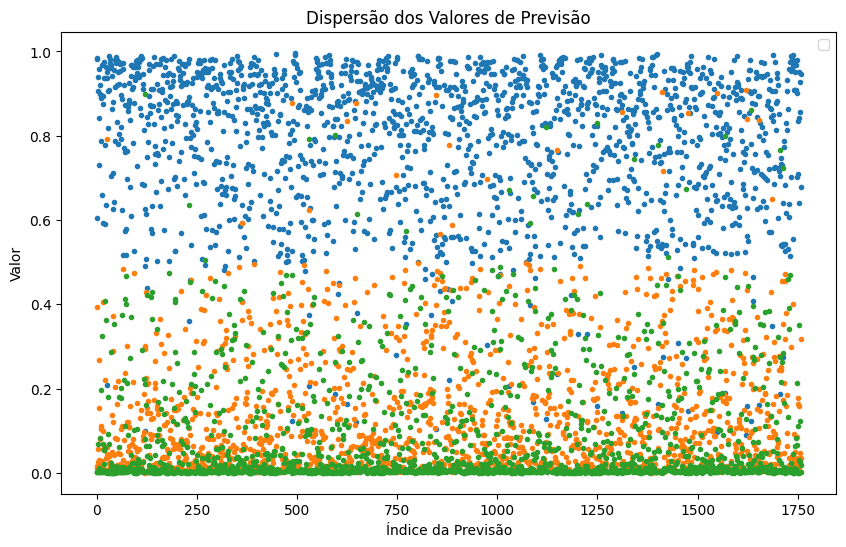

In [58]:
import matplotlib.pyplot as plt

# Plotar o gráfico scatter

idxs = [i for i, (x, y) in enumerate(zip(labels, signals)) if x.lower() == y.lower()]

plt.figure(figsize=(10, 6))
for i in range(label_pred.shape[1]):
    #plt.scatter(np.arange(len(label_pred)), label_pred[:, i], label=f'Classe {i}')

    plt.scatter(np.arange(len(label_pred[idxs, i])), label_pred[idxs, i], marker='.')

plt.xlabel('Índice da Previsão')
plt.ylabel('Valor')
plt.title('Dispersão dos Valores de Previsão')
plt.legend()
plt.show()

In [59]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score

# Calcule a curva ROC para cada classe
for i in range(label_pred.shape[1]):
    fpr, tpr, thresholds = roc_curve(label_data[40:, i], label_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Encontre o valor de threshold que maximize a área sob a curva ROC
    idx = np.argmax(tpr - fpr)
    th = thresholds[idx]
    
    # Avalie o desempenho do modelo com o valor de threshold encontrado
    y_pred = (label_pred[:, i] >= th).astype(int)
    accuracy = accuracy_score(label_data[40:, i], y_pred)
    
    print(f'Classe {i}: th = {th:.2f}, Acurácia = {accuracy:.2f}')

Classe 0: th = 0.43, Acurácia = 0.75
Classe 1: th = 0.35, Acurácia = 0.80
Classe 2: th = 0.13, Acurácia = 0.75


In [60]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.0001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

147/147 [==============================] - 2s 12ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([ 553, 3545,  593], dtype=int64))


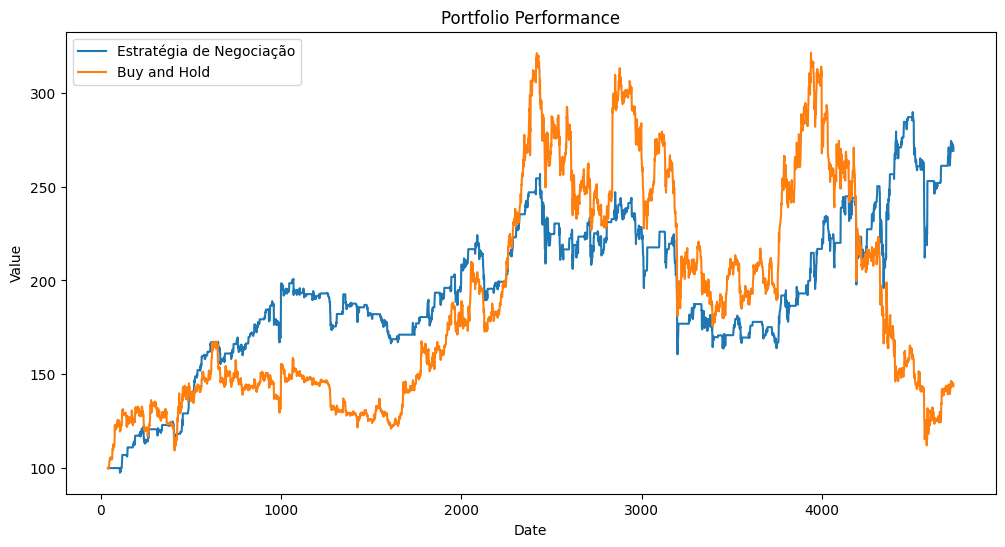

Retorno da Estratégia de Negociação: 169.14%
Retorno da Estratégia de Buy and Hold: 43.61%


In [73]:


# Parâmetros iniciais
interval = '4h'
start_time = '2023-01-01'
initial_balance = 100

symbol = cryptos
# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    if datatype == '2D':
        x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    #list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name=f'CNN_MultiHead_{datatype}'
    label_pred = trained_best_models[model_name].predict(x_data)

    #signals = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    #TH = [0.5, 0.7, 0.55]
    TH = [0.5, 0.75, 0.65]
    #TH = [0.5, 0.4, 0.40]
    TH = [0.5, 0.6, 0.4]
    signals = np.array([
        trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
        for prediction in label_pred
    ])


    print(np.unique(signals, return_counts=True))
    trade_signals=generate_signals(signals)
    
    #trade_signals=signals
    data=data.iloc[-len(signals):,:]


    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    #backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals = ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([  878, 13150,  1461], dtype=int64))


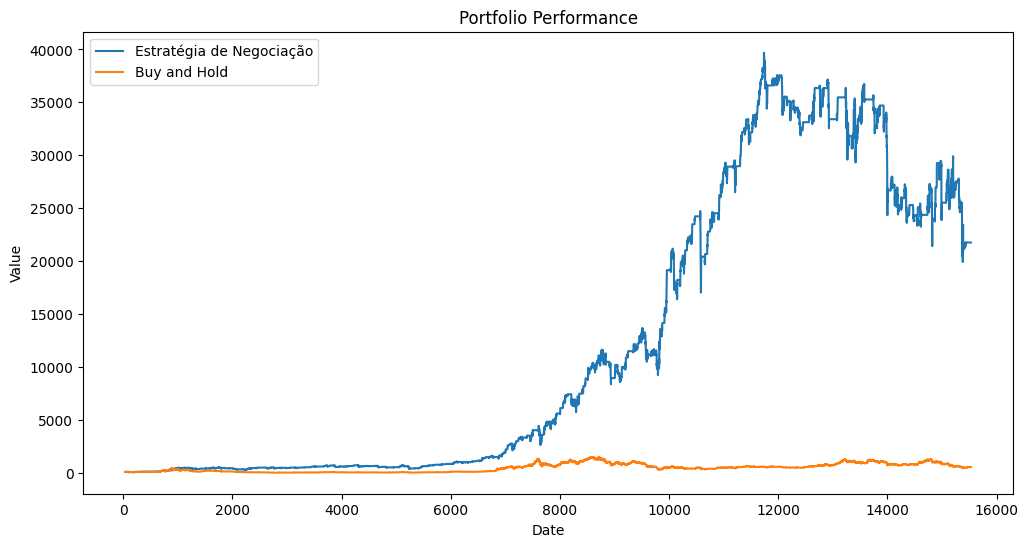

Modelo: {'Final Portfolio Value': 21767.044262781088, 'ROI (%)': 21667.044262781088, 'Max Drawdown (%)': -28.79820194441508}
BuyHold: {'Final Portfolio Value': 578.0412589472351, 'ROI (%)': 478.0412589472351, 'Max Drawdown (%)': -73.97802527395957}


In [62]:
TH = [0.5, 0.8, 0.6]
#TH = [0.5, 0.4, 0.40]
signals = np.array([
    trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
    for prediction in label_pred
])


print(np.unique(signals, return_counts=True))
trade_signals=generate_signals(signals)

#trade_signals=signals
data=data.iloc[-len(signals):,:]


backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)
#backtester.plot_results()

# Estratégia de buy and hold
buy_and_hold = Backtester(initial_balance, data)
signals = ['Buy'] + ['Hold'] * (len(data) - 1)
buy_and_hold.run(signals)
buy_and_hold_value = buy_and_hold.portfolio_value

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular retorno
backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

#print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
#print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

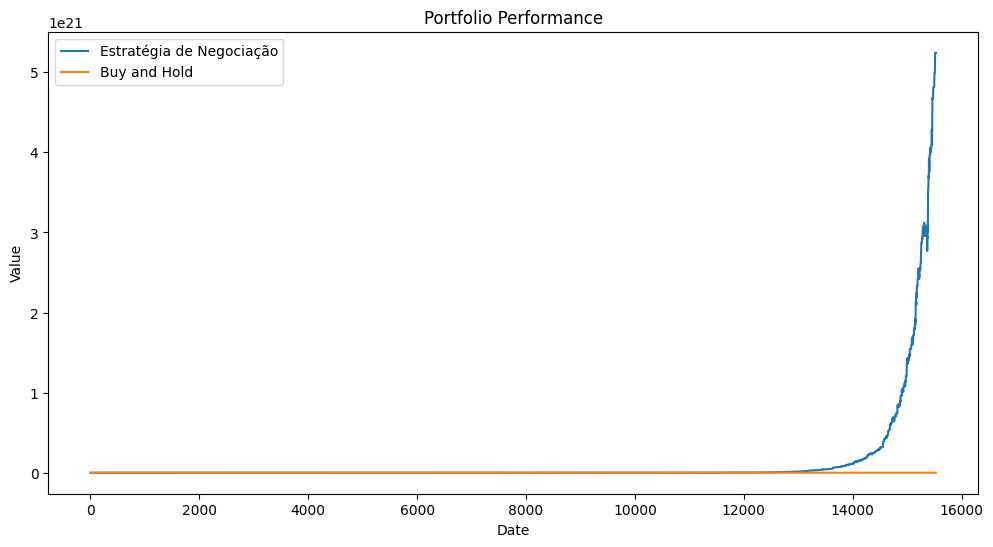

Retorno da Estratégia de Negociação: 5243892523553836236800.00%
Retorno da Estratégia de Buy and Hold: 492.87%


In [63]:
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=16)

trade_signals=[("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
        for label in label_data]# Realizar o backtest

data=data.iloc[:len(trade_signals),:]

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Estratégia de buy and hold
buy_and_hold = Backtester(initial_balance, data)
signals = ['Buy'] + ['Hold'] * (len(data) - 1)
buy_and_hold.run(signals)
buy_and_hold_value = buy_and_hold.portfolio_value

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular retorno
backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

### Save the best Th in json file 

In [74]:
TH

[0.5, 0.6, 0.4]

In [75]:
parameters['TH'] = TH

# Salve o arquivo JSON novamente
with open(f'{checkpoint_filepath}/config.json', 'w') as file:
    json.dump(parameters, file, indent=4)